In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Shape:", df.shape)
print("\nTarget classes:", wine.target_names)
print("\nClass distribution:\n", df['target'].value_counts())
print("\nFirst 5 rows:\n", df.head())

Shape: (178, 14)

Target classes: ['class_0' 'class_1' 'class_2']

Class distribution:
 target
1    71
0    59
2    48
Name: count, dtype: int64

First 5 rows:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18        

In [3]:
X = wine.data
y = wine.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 13)
y shape: (178,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (142, 13)
Testing size: (36, 13)


In [5]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_gnb = gnb.predict(X_test)

print("=== Gaussian Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gnb, target_names=wine.target_names))

=== Gaussian Naive Bayes ===
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [6]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

print("=== Multinomial Naive Bayes ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mnb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mnb, target_names=wine.target_names))

=== Multinomial Naive Bayes ===
Accuracy: 0.8888888888888888

Classification Report:
               precision    recall  f1-score   support

     class_0       0.88      1.00      0.93        14
     class_1       0.93      0.93      0.93        14
     class_2       0.83      0.62      0.71         8

    accuracy                           0.89        36
   macro avg       0.88      0.85      0.86        36
weighted avg       0.89      0.89      0.88        36



In [7]:
gnb_acc = accuracy_score(y_test, y_pred_gnb)
mnb_acc = accuracy_score(y_test, y_pred_mnb)

print("Gaussian NB Accuracy  :", round(gnb_acc * 100, 2), "%")
print("Multinomial NB Accuracy:", round(mnb_acc * 100, 2), "%")

if gnb_acc > mnb_acc:
    print("\n✅ Gaussian Naive Bayes performs BETTER!")
else:
    print("\n✅ Multinomial Naive Bayes performs BETTER!")

Gaussian NB Accuracy  : 100.0 %
Multinomial NB Accuracy: 88.89 %

✅ Gaussian Naive Bayes performs BETTER!


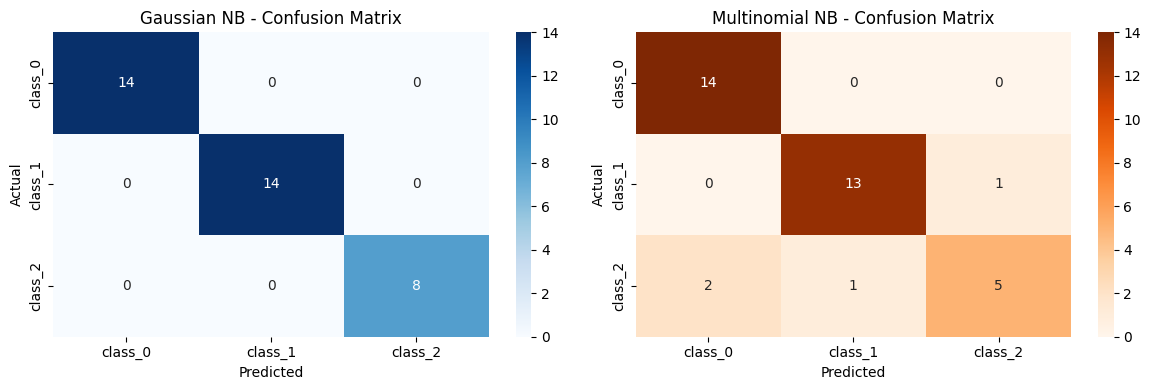

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gaussian
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names, ax=axes[0])
axes[0].set_title("Gaussian NB - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Multinomial
cm_mnb = confusion_matrix(y_test, y_pred_mnb)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names, ax=axes[1])
axes[1].set_title("Multinomial NB - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [9]:
print("Sample predictions using Gaussian NB:\n")
print(f"{'Actual':<15} {'Predicted':<15}")
print("-" * 30)

for actual, predicted in zip(y_test[:10], y_pred_gnb[:10]):
    actual_name    = wine.target_names[actual]
    predicted_name = wine.target_names[predicted]
    match = "✅" if actual == predicted else "❌"
    print(f"{actual_name:<15} {predicted_name:<15} {match}")

Sample predictions using Gaussian NB:

Actual          Predicted      
------------------------------
class_0         class_0         ✅
class_0         class_0         ✅
class_2         class_2         ✅
class_0         class_0         ✅
class_1         class_1         ✅
class_0         class_0         ✅
class_1         class_1         ✅
class_2         class_2         ✅
class_1         class_1         ✅
class_2         class_2         ✅
